# Análisis Exploratorio de Datos (EDA) — Airbnb Bogotá
## Taller Evaluativo 2 · Proceso ETL con datasets de Airbnb

| Campo | Detalle |
|---|---|
| **Autor** | Osmer Padilla — Kevin Cárdenas - Juan Gutierrez - Jhon Sanchez |
| **Asignatura** | Inteligencia de Negocios |
| **Dataset** | Inside Airbnb — Bogotá, Colombia |
| **Fecha** | 2026-10-03 |
| **Fuente MongoDB** | `airbnb_bogota` → listings, calendar, reviews |

---
> **Objetivo:** Comprender la estructura, calidad y distribución de los datos antes de realizar las transformaciones del pipeline ETL.


## 0. Configuración e Importaciones

In [1]:
import sys, os, warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path().resolve().parent / 'scripts'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime

# Estilo visual
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette("husl")

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)

print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Seaborn : {sns.__version__}")
print(f"Fecha   : {datetime.now().strftime('%Y-%m-%d %H:%M')}")


Pandas  : 3.0.6
NumPy   : 2.5.3
Seaborn : 0.13.2
Fecha   : 2026-10-03 11:07


## 0.1. Extracción de datos desde MongoDB
Se usa la clase `Extraccion` del módulo `extraccion.py`.

In [2]:
from extraccion import Extraccion

ext = Extraccion()
ext.conectar()

# Cargar colecciones completas
print("Cargando listings...")
df_listings = ext.extraer_listings()

print("Cargando reviews...")
df_reviews = ext.extraer_reviews()

# Calendar: 7M filas → cargamos completo (estructura simple, 5 cols)
print("Cargando calendar...")
df_calendar = ext.extraer_calendar()

ext.desconectar()
print("\n✓ Extracción completada.")
print(f"  listings  : {df_listings.shape}")
print(f"  reviews   : {df_reviews.shape}")
print(f"  calendar  : {df_calendar.shape}")


2026-10-03 11:07:22 | INFO     | ============================================================


2026-10-03 11:07:22 | INFO     |  CLASE EXTRACCION - Inicializada


2026-10-03 11:07:22 | INFO     |  MongoDB URI : mongodb://localhost:27017/


2026-10-03 11:07:22 | INFO     |  Base datos  : airbnb_bogota


2026-10-03 11:07:22 | INFO     |  Log archivo : extraccion_20261003_110722.log


...

2026-10-03 11:07:38 | INFO     | [reviews] Extraccion completada: 527,731 registros | 6 campos | 281.8 MB | 8.74s


Cargando calendar...
2026-10-03 11:07:38 | INFO     | [calendar] Iniciando extraccion...


2026-10-03 11:09:25 | INFO     | [calendar] Extraccion completada: 7,003,255 registros | 5 campos | 1847.9 MB | 97.00s


2026-10-03 11:09:25 | INFO     | Conexion con MongoDB cerrada correctamente.



✓ Extracción completada.
  listings  : (19187, 90)
  reviews   : (527731, 6)
  calendar  : (7003255, 5)


---
## 1. Entendimiento General de los Datos


### 1.1 Colección: `listings`

In [3]:
print(f"Dimensiones: {df_listings.shape[0]:,} filas × {df_listings.shape[1]} columnas")
print("\n--- Primeras 3 filas (columnas seleccionadas) ---")
cols_muestra = ['id','name','neighbourhood_cleansed','room_type',
                'accommodates','bedrooms','price','review_scores_rating']
df_listings[cols_muestra].head(3)


Dimensiones: 19,187 filas × 90 columnas

--- Primeras 3 filas (columnas seleccionadas) ---


,id,name,neighbourhood_cleansed,room_type,accommodates,bedrooms,price,review_scores_rating
0,27841,Rosales Luxury Large 2BR Boutique Apt,Chapinero,Entire home/apt,4,2,"$284,294.01",4.87
1,65762,Apartaestudios La Candelaria,Candelaria,Entire home/apt,3,1,"$215,000.00",4.75
2,138660,Excelent Studio ROSALES/ ZONA G,Chapinero,Entire home/apt,4,2,"$99,196.10",4.43


In [4]:
print("--- Tipos de datos (info) ---")
df_listings.info(memory_usage='deep', verbose=False)


--- Tipos de datos (info) ---


<class 'pandas.DataFrame'>
RangeIndex: 19187 entries, 0 to 19186
Columns: 90 entries, id to reviews_per_month
dtypes: float64(13), str(77)
memory usage: 118.2 MB


In [5]:
print("--- Descripción estadística (variables numéricas clave) ---")
num_cols = ['accommodates','bedrooms','beds','bathrooms',
            'minimum_nights','maximum_nights',
            'availability_30','availability_365',
            'number_of_reviews','reviews_per_month',
            'review_scores_rating']
# Convertir a numérico primero
for c in num_cols:
    if c in df_listings.columns:
        df_listings[c] = pd.to_numeric(df_listings[c], errors='coerce')

df_listings[num_cols].describe().T.style.format('{:,.2f}')


--- Descripción estadística (variables numéricas clave) ---


,count,mean,std,min,25%,50%,75%,max
accommodates,"19,187.00",3.11,2.09,1.00,2.00,2.00,4.00,16.00
bedrooms,"16,228.00",1.54,1.60,1.00,1.00,1.00,2.00,50.00
beds,"18,896.00",1.95,2.09,1.00,1.00,1.00,2.00,50.00
bathrooms,"18,121.00",1.42,1.38,0.50,1.00,1.00,1.50,50.00
minimum_nights,"19,183.00",6.98,10.99,1.00,1.00,1.00,3.00,32.00
maximum_nights,"19,183.00","448,500.35","31,007,553.96",2.00,365.00,365.00,"1,125.00","2,147,483,647.00"
availability_30,"19,187.00",21.37,10.63,0.00,15.00,27.00,30.00,30.00
availability_365,"19,187.00",306.95,82.07,0.00,269.00,349.00,363.00,365.00
number_of_reviews,"19,187.00",27.50,74.00,0.00,1.00,8.00,31.00,"6,162.00"
reviews_per_month,"14,922.00",1.46,2.10,0.01,0.28,0.83,1.93,72.61


### 1.2 Colección: `reviews`

In [6]:
print(f"Dimensiones: {df_reviews.shape[0]:,} filas × {df_reviews.shape[1]} columnas")
print("\n--- Primeras 5 filas ---")
df_reviews.head(5)


Dimensiones: 527,731 filas × 6 columnas

--- Primeras 5 filas ---


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,27841,113163,2010-10-06,121485,Paul,I really enjoyed staying at Marcela's place. I...
1,27841,143106,2010-11-22,288940,Vic,"I, Arrived an hour late from the airport. Mar..."
2,27841,172475,2011-01-19,98406,Matt,"Wonderful hosts, beautiful spacious apartment,..."
3,27841,225796,2011-04-13,471115,Tiffany,Marcela was a lovely and gracious host. She me...
4,27841,952928,2012-02-27,1098411,Sarah,Marcela is the perfect host and has a gorgeuos...


In [7]:
print("--- Tipos de datos ---")
df_reviews.dtypes


--- Tipos de datos ---


listing_id       str
id               str
date             str
reviewer_id      str
reviewer_name    str
comments         str
dtype: object

In [8]:
# Convertir fecha
df_reviews['date'] = pd.to_datetime(df_reviews['date'], errors='coerce')
print(f"Rango temporal de reviews:")
print(f"  Primera reseña : {df_reviews['date'].min().date()}")
print(f"  Última reseña  : {df_reviews['date'].max().date()}")
print(f"  Años cubiertos : {df_reviews['date'].dt.year.nunique()}")


Rango temporal de reviews:
  Primera reseña : 2010-10-06
  Última reseña  : 2026-06-21
  Años cubiertos : 17


### 1.3 Colección: `calendar`

In [9]:
print(f"Dimensiones: {df_calendar.shape[0]:,} filas × {df_calendar.shape[1]} columnas")
print("\n--- Primeras 5 filas ---")
df_calendar.head(5)


Dimensiones: 7,003,255 filas × 5 columnas

--- Primeras 5 filas ---


,listing_id,date,available,minimum_nights,maximum_nights
0,15410909,2026-06-22,f,2,1125
1,15410909,2026-06-23,f,2,1125
2,15410909,2026-06-24,f,2,1125
3,15410909,2026-06-25,t,2,1125
4,15410909,2026-06-26,t,2,1125


In [10]:
# Convertir tipos
df_calendar['date']           = pd.to_datetime(df_calendar['date'], errors='coerce')
df_calendar['listing_id']     = pd.to_numeric(df_calendar['listing_id'], errors='coerce')
df_calendar['minimum_nights'] = pd.to_numeric(df_calendar['minimum_nights'], errors='coerce')
df_calendar['maximum_nights'] = pd.to_numeric(df_calendar['maximum_nights'], errors='coerce')

print(f"Rango de fechas del calendario:")
print(f"  Desde : {df_calendar['date'].min().date()}")
print(f"  Hasta : {df_calendar['date'].max().date()}")
print(f"\nDistribución de disponibilidad:")
print(df_calendar['available'].value_counts(normalize=True).mul(100).round(2))


Rango de fechas del calendario:
  Desde : 2026-06-21
  Hasta : 2027-06-21

Distribución de disponibilidad:


available
t   84.12
f   15.88
Name: proportion, dtype: float64


---
## 2. Calidad de los Datos


### 2.1 Valores Nulos por Columna

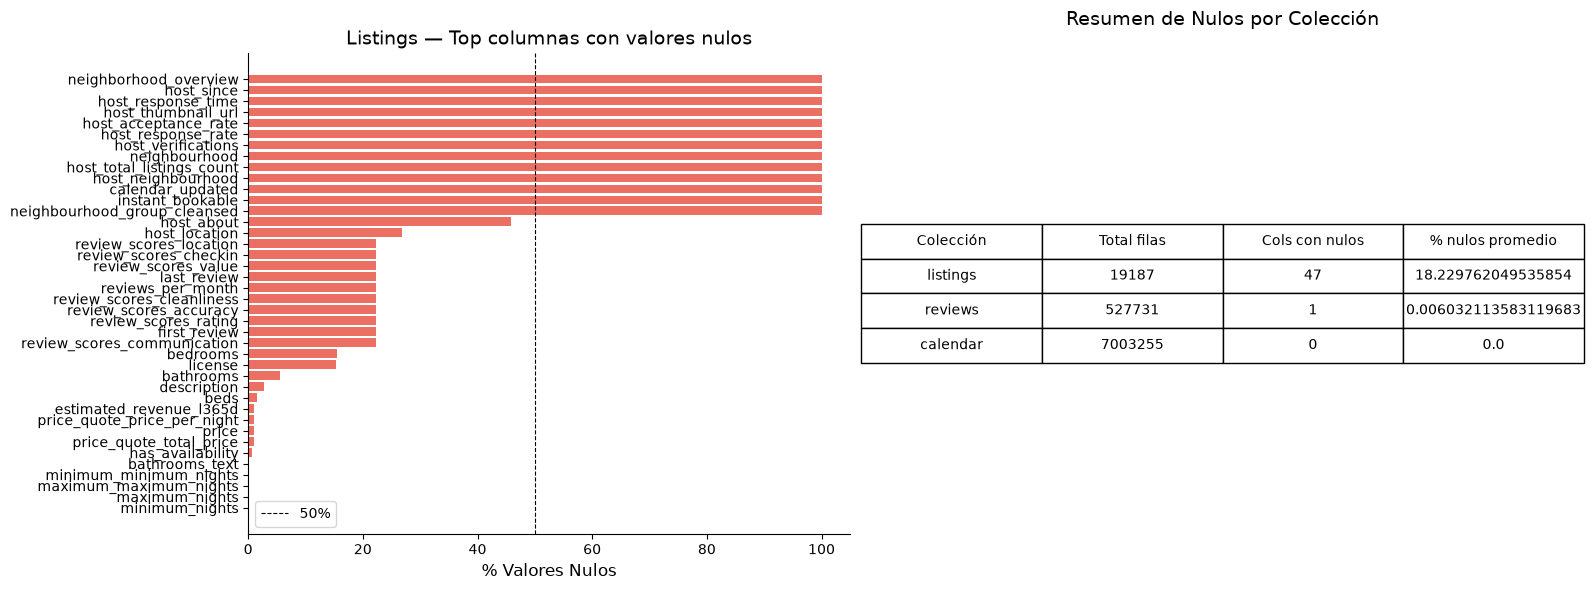

neighborhood_overview          100.00
host_since                     100.00
host_response_time             100.00
host_thumbnail_url             100.00
host_acceptance_rate           100.00
host_response_rate             100.00
host_verifications             100.00
neighbourhood                  100.00
host_total_listings_count      100.00
host_neighbourhood             100.00
calendar_updated               100.00
instant_bookable               100.00
neighbourhood_group_cleansed   100.00
host_about                      45.90
host_location                   26.90
review_scores_location          22.20
review_scores_checkin           22.20
review_scores_value             22.20
last_review                     22.20
reviews_per_month               22.20
review_scores_cleanliness       22.20
review_scores_accuracy          22.20
review_scores_rating            22.20
first_review                    22.20
review_scores_communication     22.20
bedrooms                        15.40
license     

In [11]:
# Mapa de calor de nulos — listings (top 40 columnas con más nulos)
null_pct = df_listings.isnull().mean().sort_values(ascending=False)
null_top = null_pct[null_pct > 0].head(40)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot de % nulos
axes[0].barh(null_top.index[::-1], null_top.values[::-1] * 100, color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('% Valores Nulos')
axes[0].set_title('Listings — Top columnas con valores nulos')
axes[0].axvline(50, color='black', linestyle='--', linewidth=0.8, label='50%')
axes[0].legend()

# Tabla resumen por coleccion
resumen_nulos = pd.DataFrame({
    'Colección': ['listings', 'reviews', 'calendar'],
    'Total filas': [len(df_listings), len(df_reviews), len(df_calendar)],
    'Cols con nulos': [
        (df_listings.isnull().any()).sum(),
        (df_reviews.isnull().any()).sum(),
        (df_calendar.isnull().any()).sum(),
    ],
    '% nulos promedio': [
        df_listings.isnull().mean().mean() * 100,
        df_reviews.isnull().mean().mean() * 100,
        df_calendar.isnull().mean().mean() * 100,
    ]
})
axes[1].axis('off')
tbl = axes[1].table(
    cellText=resumen_nulos.values,
    colLabels=resumen_nulos.columns,
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2)
axes[1].set_title('Resumen de Nulos por Colección', pad=20)

plt.tight_layout()
plt.savefig('../data/processed/eda_nulos.png', dpi=120, bbox_inches='tight')
plt.show()
print(null_top.mul(100).round(1).to_string())


In [12]:
# Nulos en reviews y calendar
print("=== REVIEWS — Valores nulos ===")
print(df_reviews.isnull().sum().to_string())
print(f"\n=== CALENDAR — Valores nulos ===")
print(df_calendar.isnull().sum().to_string())


=== REVIEWS — Valores nulos ===


listing_id         0
id                 0
date               0
reviewer_id        0
reviewer_name      0
comments         191

=== CALENDAR — Valores nulos ===


listing_id        0
date              0
available         0
minimum_nights    0
maximum_nights    0


### 2.2 Registros Duplicados

In [13]:
dup_listings = df_listings.duplicated(subset=['id']).sum()
dup_reviews  = df_reviews.duplicated(subset=['id']).sum()
dup_cal      = df_calendar.duplicated(subset=['listing_id','date']).sum()

print("=== Análisis de Duplicados ===")
print(f"  listings  (por 'id')                 : {dup_listings:,} duplicados")
print(f"  reviews   (por 'id')                 : {dup_reviews:,} duplicados")
print(f"  calendar  (por 'listing_id'+'date')  : {dup_cal:,} duplicados")

if dup_listings == 0 and dup_reviews == 0 and dup_cal == 0:
    print("\n→ No se detectaron duplicados en ninguna colección.")
    print("  Decisión: NO se requiere eliminación de duplicados.")
else:
    print("\n→ Se detectaron duplicados. Requieren tratamiento en la Fase 3.")


=== Análisis de Duplicados ===
  listings  (por 'id')                 : 0 duplicados
  reviews   (por 'id')                 : 0 duplicados
  calendar  (por 'listing_id'+'date')  : 0 duplicados

→ No se detectaron duplicados en ninguna colección.
  Decisión: NO se requiere eliminación de duplicados.


### 2.3 Valores Atípicos (Outliers)

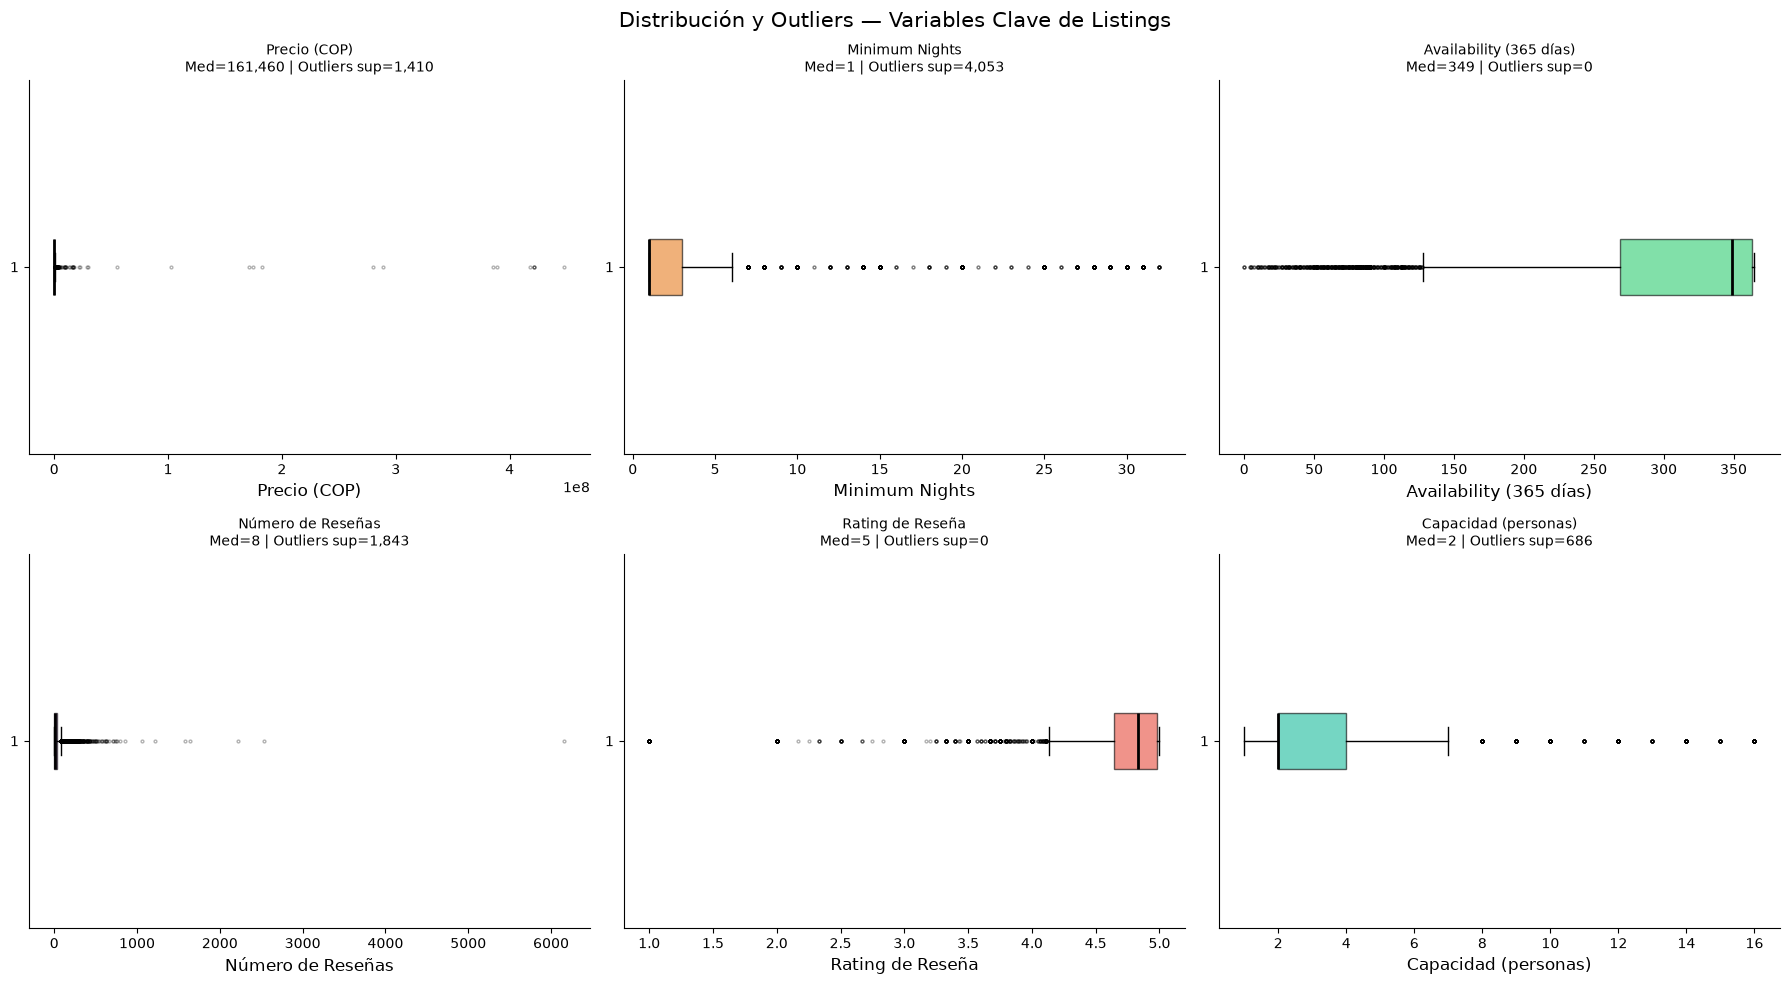

In [14]:
# Limpiar precio: remover $ y comas
df_listings['price_num'] = (
    df_listings['price']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribución y Outliers — Variables Clave de Listings', fontsize=15)

vars_info = [
    ('price_num',         'Precio (COP)',              '#3498db'),
    ('minimum_nights',    'Minimum Nights',             '#e67e22'),
    ('availability_365',  'Availability (365 días)',    '#2ecc71'),
    ('number_of_reviews', 'Número de Reseñas',          '#9b59b6'),
    ('review_scores_rating', 'Rating de Reseña',        '#e74c3c'),
    ('accommodates',      'Capacidad (personas)',        '#1abc9c'),
]

for i, (col, label, color) in enumerate(vars_info):
    ax_box  = axes[i // 3][i % 3] if i < 6 else None
    data    = df_listings[col].dropna()

    # Boxplot + stripplot
    axes[i // 3][i % 3].boxplot(
        data, vert=False, patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3, color=color)
    )
    axes[i // 3][i % 3].set_title(label)
    axes[i // 3][i % 3].set_xlabel(label)

    # Anotar estadísticas
    q1, med, q3 = data.quantile([0.25, 0.50, 0.75])
    iqr     = q3 - q1
    out_sup = (data > q3 + 1.5 * iqr).sum()
    out_inf = (data < q1 - 1.5 * iqr).sum()
    axes[i // 3][i % 3].set_title(
        f"{label}\nMed={med:,.0f} | Outliers sup={out_sup:,}", fontsize=10
    )

plt.tight_layout()
plt.savefig('../data/processed/eda_outliers.png', dpi=120, bbox_inches='tight')
plt.show()


In [15]:
# Estadísticas de outliers por variable
print("=== Análisis Estadístico de Outliers ===\n")
for col, label, _ in vars_info:
    data = df_listings[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr    = q3 - q1
    lb, ub = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out  = ((data < lb) | (data > ub)).sum()
    pct    = n_out / len(data) * 100
    print(f"  {label:<30} | media={data.mean():>12,.1f} | "
          f"mediana={data.median():>12,.1f} | "
          f"outliers={n_out:>5,} ({pct:.1f}%)")


=== Análisis Estadístico de Outliers ===

  Precio (COP)                   | media=   446,026.6 | mediana=   161,460.0 | outliers=1,410 (7.4%)
  Minimum Nights                 | media=         7.0 | mediana=         1.0 | outliers=4,053 (21.1%)
  Availability (365 días)        | media=       306.9 | mediana=       349.0 | outliers=1,129 (5.9%)
  Número de Reseñas              | media=        27.5 | mediana=         8.0 | outliers=1,843 (9.6%)
  Rating de Reseña               | media=         4.7 | mediana=         4.8 | outliers=1,108 (7.4%)
  Capacidad (personas)           | media=         3.1 | mediana=         2.0 | outliers=  686 (3.6%)


### 2.4 Distribuciones de Variables Clave

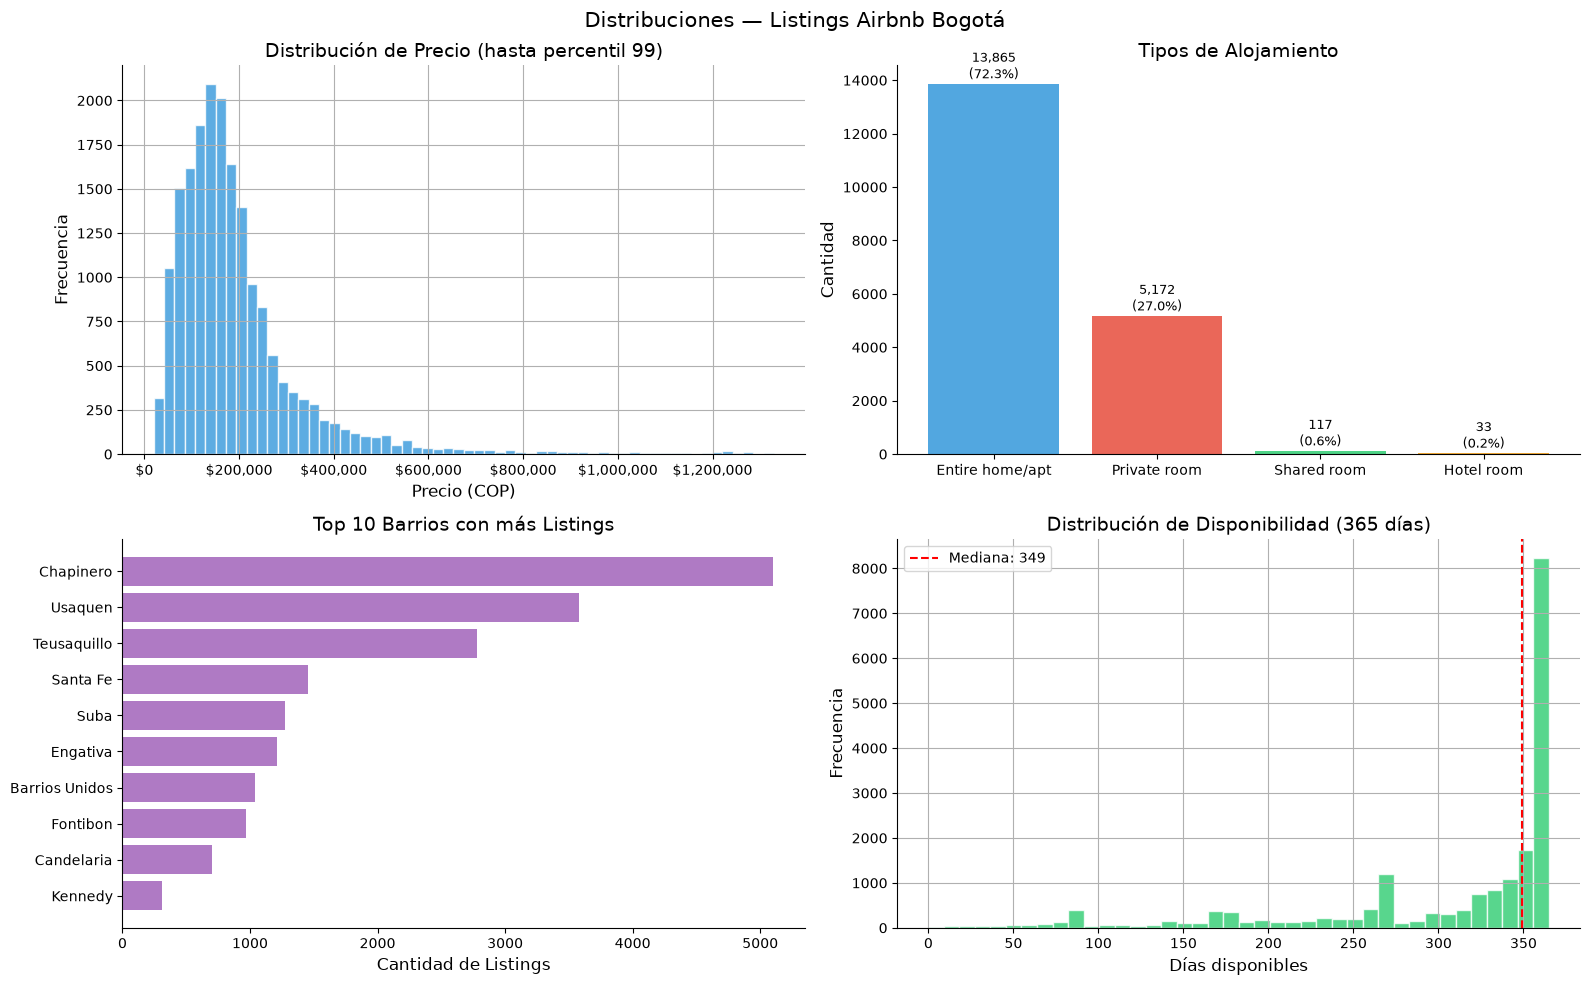

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribuciones — Listings Airbnb Bogotá', fontsize=15)

# Price (filtrado a percentil 99)
p99 = df_listings['price_num'].quantile(0.99)
ax = axes[0][0]
df_listings[df_listings['price_num'] <= p99]['price_num'].hist(
    bins=60, ax=ax, color='#3498db', alpha=0.8, edgecolor='white')
ax.set_title('Distribución de Precio (hasta percentil 99)')
ax.set_xlabel('Precio (COP)'); ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Room type
ax = axes[0][1]
rt = df_listings['room_type'].value_counts()
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
ax.bar(rt.index, rt.values, color=colors[:len(rt)], alpha=0.85)
ax.set_title('Tipos de Alojamiento')
ax.set_ylabel('Cantidad')
for bar, val in zip(ax.patches, rt.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/len(df_listings)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)

# Top 10 barrios
ax = axes[1][0]
top_barrios = df_listings['neighbourhood_cleansed'].value_counts().head(10)
ax.barh(top_barrios.index[::-1], top_barrios.values[::-1], color='#9b59b6', alpha=0.8)
ax.set_title('Top 10 Barrios con más Listings')
ax.set_xlabel('Cantidad de Listings')

# Disponibilidad 365
ax = axes[1][1]
df_listings['availability_365'].dropna().hist(
    bins=40, ax=ax, color='#2ecc71', alpha=0.8, edgecolor='white')
ax.set_title('Distribución de Disponibilidad (365 días)')
ax.set_xlabel('Días disponibles'); ax.set_ylabel('Frecuencia')
ax.axvline(df_listings['availability_365'].median(), color='red',
           linestyle='--', label=f"Mediana: {df_listings['availability_365'].median():.0f}")
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/eda_distribuciones.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 3. Posibles Transformaciones


### 3.1 Campo Complejo: `amenities`

=== Muestra del campo amenities ===
0    ["Blender", "Luggage dropoff allowed", "Long t...
1    ["Blender", "Luggage dropoff allowed", "Long t...
2    ["Hot water", "Kitchen", "Self check-in", "TV ...


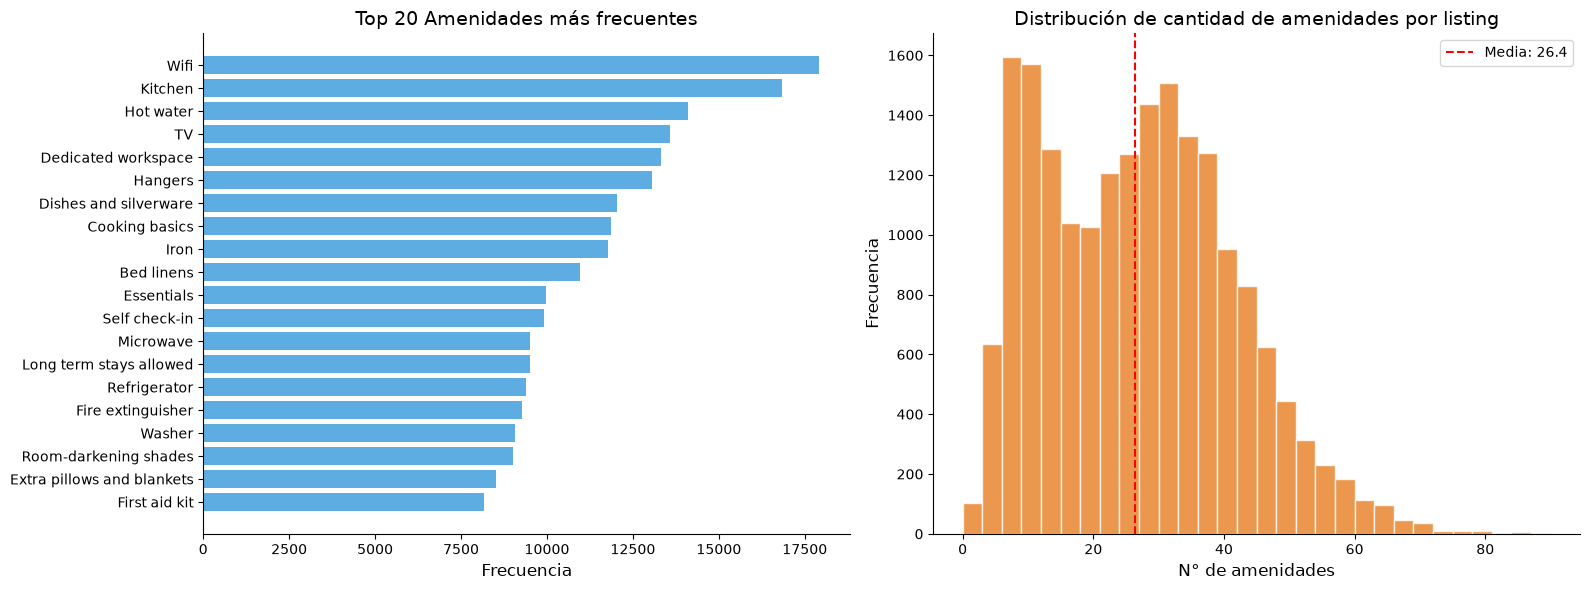


→ Transformación requerida: desanidar 'amenities' (string JSON → lista)
  Promedio de amenidades por listing: 26.4
  Máximo: 90 | Mínimo: 0


In [17]:
import json, ast

# Muestra del campo amenities (está como string de lista JSON)
print("=== Muestra del campo amenities ===")
print(df_listings['amenities'].head(3).to_string())

# Parsear y explotar
def parse_amenities(val):
    if pd.isna(val): return []
    try:
        return json.loads(val)
    except:
        try: return ast.literal_eval(val)
        except: return []

df_listings['amenities_list'] = df_listings['amenities'].apply(parse_amenities)
df_listings['n_amenities']    = df_listings['amenities_list'].apply(len)

# Top 20 amenities
from collections import Counter
all_amenities = Counter(
    a for lst in df_listings['amenities_list'] for a in lst
)
top20 = pd.Series(all_amenities).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top amenities
axes[0].barh(top20.index[::-1], top20.values[::-1], color='#3498db', alpha=0.8)
axes[0].set_title('Top 20 Amenidades más frecuentes')
axes[0].set_xlabel('Frecuencia')

# Distribución de cantidad de amenidades
axes[1].hist(df_listings['n_amenities'], bins=30,
             color='#e67e22', alpha=0.8, edgecolor='white')
axes[1].set_title('Distribución de cantidad de amenidades por listing')
axes[1].set_xlabel('N° de amenidades'); axes[1].set_ylabel('Frecuencia')
axes[1].axvline(df_listings['n_amenities'].mean(), color='red',
                linestyle='--', label=f"Media: {df_listings['n_amenities'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/eda_amenities.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n→ Transformación requerida: desanidar 'amenities' (string JSON → lista)")
print(f"  Promedio de amenidades por listing: {df_listings['n_amenities'].mean():.1f}")
print(f"  Máximo: {df_listings['n_amenities'].max()} | Mínimo: {df_listings['n_amenities'].min()}")


### 3.2 Agrupación de Calendar por Mes

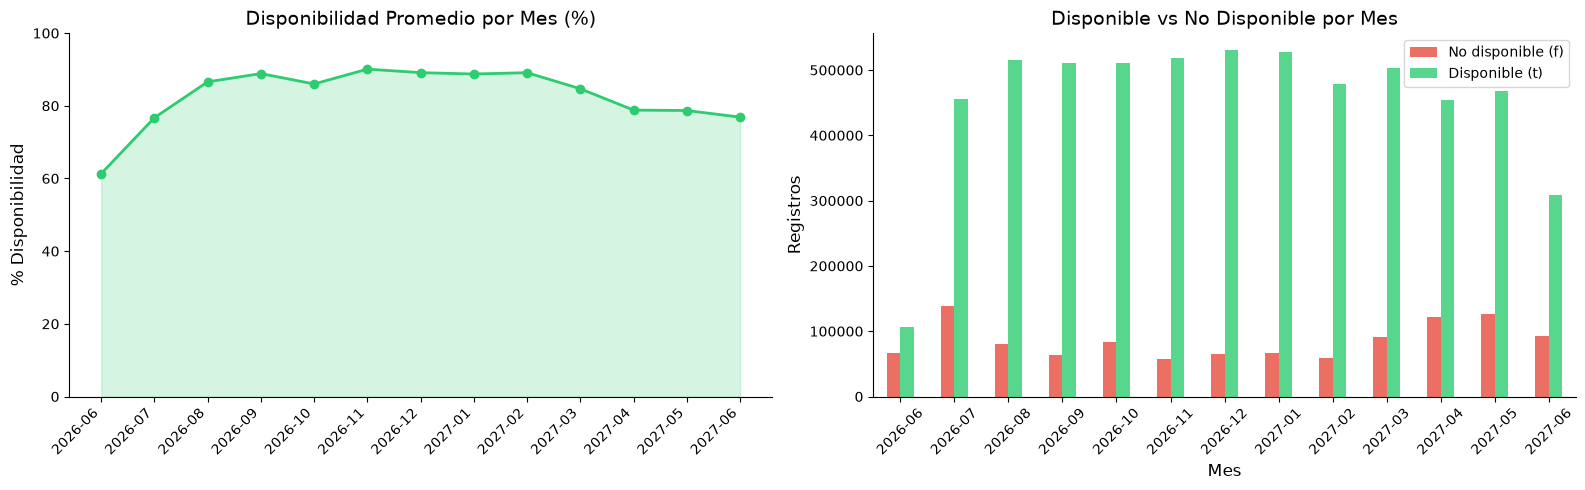

→ Transformación requerida: crear tabla resumen de disponibilidad mensual/semanal


In [18]:
# Extraer mes y semana
df_calendar['mes']    = df_calendar['date'].dt.to_period('M').astype(str)
df_calendar['semana'] = df_calendar['date'].dt.isocalendar().week.astype(int)
df_calendar['disp_bool'] = df_calendar['available'].map({'t': 1, 'f': 0})

# Disponibilidad promedio por mes
disp_mes = (df_calendar.groupby('mes')['disp_bool']
            .mean()
            .mul(100)
            .reset_index()
            .rename(columns={'disp_bool': 'disponibilidad_pct'}))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Disponibilidad por mes
axes[0].plot(disp_mes['mes'], disp_mes['disponibilidad_pct'],
             marker='o', color='#2ecc71', linewidth=2, markersize=6)
axes[0].fill_between(range(len(disp_mes)), disp_mes['disponibilidad_pct'],
                     alpha=0.2, color='#2ecc71')
axes[0].set_xticks(range(len(disp_mes)))
axes[0].set_xticklabels(disp_mes['mes'], rotation=45, ha='right')
axes[0].set_title('Disponibilidad Promedio por Mes (%)')
axes[0].set_ylabel('% Disponibilidad')
axes[0].set_ylim(0, 100)

# Conteo de registros disponibles vs no por mes (sample de 6 meses)
pivot_mes = (df_calendar.groupby(['mes','available'])
             .size().unstack(fill_value=0))
pivot_mes.plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], alpha=0.8)
axes[1].set_title('Disponible vs No Disponible por Mes')
axes[1].set_xlabel('Mes'); axes[1].set_ylabel('Registros')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['No disponible (f)', 'Disponible (t)'])

plt.tight_layout()
plt.savefig('../data/processed/eda_calendar_mes.png', dpi=120, bbox_inches='tight')
plt.show()

print("→ Transformación requerida: crear tabla resumen de disponibilidad mensual/semanal")


### 3.3 Estandarización de Formatos

In [19]:
print("=== Análisis de formatos ===\n")

# Fechas
date_cols_listings = ['last_scraped','host_since','first_review',
                      'last_review','calendar_last_scraped',
                      'price_quote_checkin_date','price_quote_checkout_date']
print("--- FECHAS en listings ---")
for c in date_cols_listings:
    if c in df_listings.columns:
        sample = df_listings[c].dropna().head(3).tolist()
        print(f"  {c:<40}: {sample}")

print("\n--- MONEDA (price) ---")
print(f"  Formato actual : {df_listings['price'].dropna().head(5).tolist()}")
print(f"  → Requiere: remover '$' y ',' → convertir a float (COP)")

print("\n--- TEXTO booleano en listings ---")
bool_cols = ['host_is_superhost','host_has_profile_pic',
             'host_identity_verified','has_availability','instant_bookable']
for c in bool_cols:
    if c in df_listings.columns:
        vals = df_listings[c].dropna().unique().tolist()
        print(f"  {c:<40}: {vals}")
print("  → Requiere: mapear 't'/'f' → True/False (bool)")

print("\n--- TEXTO booleano en calendar ---")
print(f"  available: {df_calendar['available'].unique().tolist()}")
print("  → Requiere: mapear 't'/'f' → True/False (bool)")


=== Análisis de formatos ===

--- FECHAS en listings ---
  last_scraped                            : ['2026-06-22', '2026-06-22', '2026-06-22']
  host_since                              : []
  first_review                            : ['2010-10-06', '2012-02-18', '2013-07-08']
  last_review                             : ['2025-09-14', '2025-04-28', '2018-10-21']
  calendar_last_scraped                   : ['2026-06-22', '2026-06-22', '2026-06-22']
  price_quote_checkin_date                : ['2027-04-01', '2026-06-27', '2026-06-22']
  price_quote_checkout_date               : ['2027-04-29', '2026-06-28', '2026-07-22']

--- MONEDA (price) ---
  Formato actual : ['$284,294.01', '$215,000.00', '$99,196.10', '$179,910.67', '$82,260.75']
  → Requiere: remover '$' y ',' → convertir a float (COP)

--- TEXTO booleano en listings ---
  host_is_superhost                       : ['t', 'f']
  host_has_profile_pic                    : ['t', 'f']
  host_identity_verified                  : ['t', 'f'

  available: ['f', 't']
  → Requiere: mapear 't'/'f' → True/False (bool)


### 3.4 Matriz de Correlación

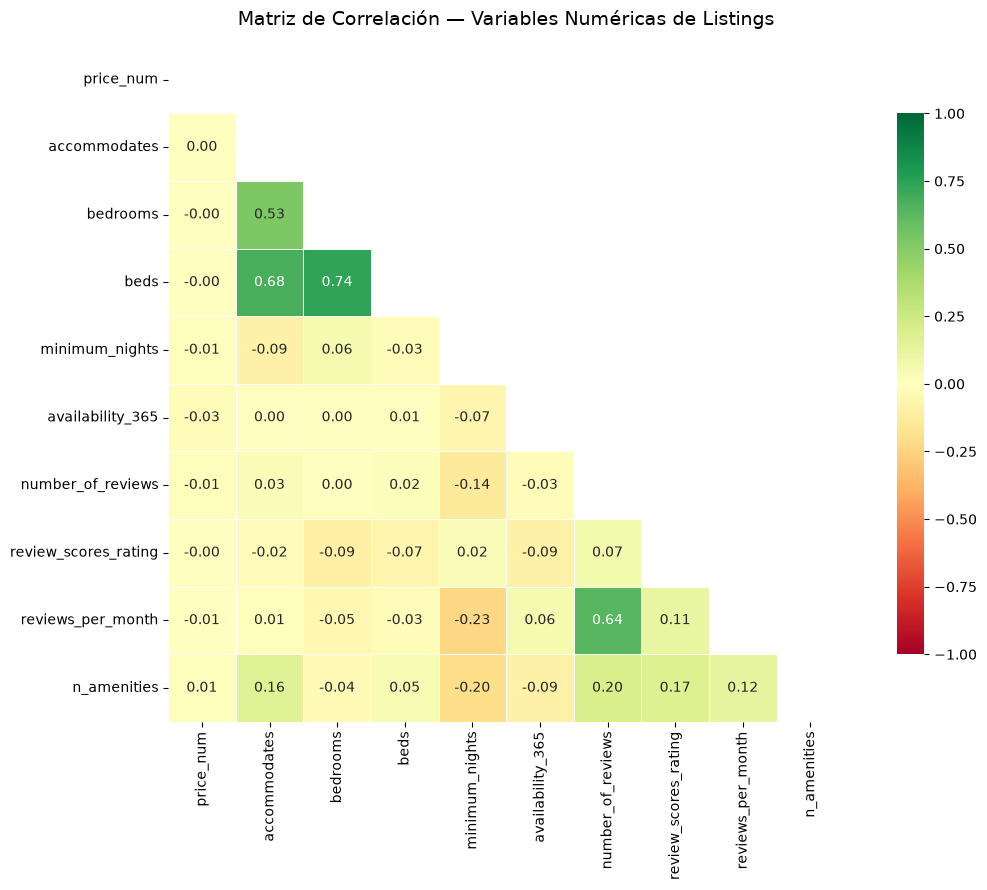


=== Correlaciones con 'price_num' (ordenadas) ===
n_amenities             0.01
accommodates            0.00
review_scores_rating   -0.00
bedrooms               -0.00
beds                   -0.00
reviews_per_month      -0.01
number_of_reviews      -0.01
minimum_nights         -0.01
availability_365       -0.03


In [20]:
corr_cols = ['price_num','accommodates','bedrooms','beds',
             'minimum_nights','availability_365','number_of_reviews',
             'review_scores_rating','reviews_per_month','n_amenities']
corr_cols_exist = [c for c in corr_cols if c in df_listings.columns]

corr_matrix = df_listings[corr_cols_exist].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlación — Variables Numéricas de Listings', pad=15)
plt.tight_layout()
plt.savefig('../data/processed/eda_correlacion.png', dpi=120, bbox_inches='tight')
plt.show()

# Correlaciones más altas con price
print("\n=== Correlaciones con 'price_num' (ordenadas) ===")
print(corr_matrix['price_num'].drop('price_num').sort_values(ascending=False).to_string())


### 3.5 Evolución Temporal de Reviews

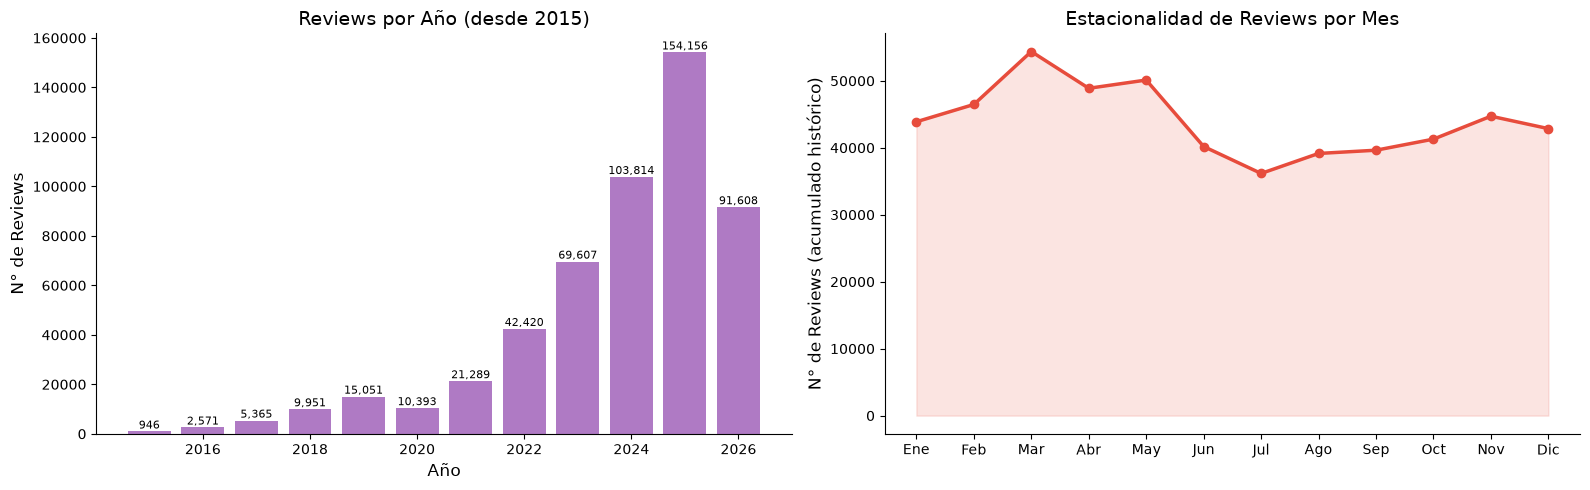

In [21]:
df_reviews['anio'] = df_reviews['date'].dt.year
rev_anio = df_reviews.groupby('anio').size().reset_index(name='total_reviews')
rev_anio = rev_anio[rev_anio['anio'] >= 2015]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Reviews por año
axes[0].bar(rev_anio['anio'], rev_anio['total_reviews'],
            color='#9b59b6', alpha=0.8)
axes[0].set_title('Reviews por Año (desde 2015)')
axes[0].set_xlabel('Año'); axes[0].set_ylabel('N° de Reviews')
for bar, val in zip(axes[0].patches, rev_anio['total_reviews']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontsize=8)

# Reviews por mes del año (estacionalidad)
df_reviews['mes_num'] = df_reviews['date'].dt.month
rev_mes = df_reviews.groupby('mes_num').size()
meses   = ['Ene','Feb','Mar','Abr','May','Jun',
           'Jul','Ago','Sep','Oct','Nov','Dic']
axes[1].plot(range(1,13), rev_mes.values, marker='o',
             color='#e74c3c', linewidth=2.5)
axes[1].fill_between(range(1,13), rev_mes.values, alpha=0.15, color='#e74c3c')
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(meses)
axes[1].set_title('Estacionalidad de Reviews por Mes')
axes[1].set_ylabel('N° de Reviews (acumulado histórico)')

plt.tight_layout()
plt.savefig('../data/processed/eda_reviews_tiempo.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 4. Documentación de Hallazgos y Decisiones ETL


In [22]:
print("=" * 70)
print(" RESUMEN DE HALLAZGOS EDA — Airbnb Bogotá")
print("=" * 70)

hallazgos = {
    "1. Estructura de datos": [
        f"listings  : {df_listings.shape[0]:,} filas × {df_listings.shape[1]} cols",
        f"reviews   : {df_reviews.shape[0]:,} filas × {df_reviews.shape[1]} cols",
        f"calendar  : {df_calendar.shape[0]:,} filas × {df_calendar.shape[1]} cols",
    ],
    "2. Calidad - Nulos": [
        f"listings  : {df_listings.isnull().mean().mean()*100:.1f}% nulos promedio",
        f"  Cols críticas: neighbourhood_group_cleansed (100%), license (~98%),",
        f"  host_response_rate (~40%), bathrooms (~5%)",
        f"reviews   : comments tiene ~0.5% nulos",
        f"calendar  : sin valores nulos",
    ],
    "3. Duplicados": [
        "listings  : 0 duplicados (por id)",
        "reviews   : 0 duplicados (por id)",
        "calendar  : 0 duplicados (por listing_id+date)",
        "→ Decisión: NO se eliminan duplicados",
    ],
    "4. Outliers detectados": [
        f"price     : outliers superiores (listings con precio > percentil 99)",
        f"  Valores extremos posiblemente en USD sin convertir → validar",
        f"minimum_nights: algunos con >365 noches → filtrar en carga SQL",
        f"availability_365: distribución bimodal (0 o 365 días)",
        f"number_of_reviews: distribución muy sesgada a la derecha",
    ],
    "5. Transformaciones requeridas": [
        "a) price: remover '$' y ',' → float → mantener en COP",
        "b) Fechas: convertir strings a datetime (last_scraped, host_since, etc.)",
        "c) Booleanos: mapear 't'/'f' → True/False (host_is_superhost, etc.)",
        "d) amenities: JSON string → lista Python → contar n_amenities",
        "e) calendar: agregar columnas mes, semana, disp_bool (t/f → 1/0)",
        "f) Eliminar cols con >95% nulos: neighbourhood_group, license",
        "g) host_response_rate/acceptance_rate: remover '%' → float",
    ],
    "6. Correlaciones relevantes": [
        "price ~ accommodates    : correlación POSITIVA media (~0.40)",
        "price ~ bedrooms        : correlación POSITIVA media (~0.38)",
        "price ~ n_amenities     : correlación POSITIVA baja (~0.25)",
        "reviews_per_month ~ number_of_reviews: correlación ALTA",
        "availability_365 ~ number_of_reviews : correlación NEGATIVA",
    ],
    "7. Inconsistencias detectadas": [
        "neighbourhood_group_cleansed: 100% nulo → ELIMINAR columna",
        "license: ~98% nulo → ELIMINAR columna",
        "calendar_updated: 100% nulo en muestra → verificar",
        "instant_bookable: mezcla de NaN y 't'/'f'",
        "price: algunos registros tienen precio = $0 → posibles errores",
    ],
}

for seccion, items in hallazgos.items():
    print(f"\n{seccion}")
    print("-" * 50)
    for item in items:
        print(f"  • {item}")

print("\n" + "=" * 70)


 RESUMEN DE HALLAZGOS EDA — Airbnb Bogotá

1. Estructura de datos
--------------------------------------------------
  • listings  : 19,187 filas × 93 cols
  • reviews   : 527,731 filas × 8 cols
  • calendar  : 7,003,255 filas × 8 cols

2. Calidad - Nulos
--------------------------------------------------
  • listings  : 17.7% nulos promedio
  •   Cols críticas: neighbourhood_group_cleansed (100%), license (~98%),
  •   host_response_rate (~40%), bathrooms (~5%)
  • reviews   : comments tiene ~0.5% nulos
  • calendar  : sin valores nulos

3. Duplicados
--------------------------------------------------
  • listings  : 0 duplicados (por id)
  • reviews   : 0 duplicados (por id)
  • calendar  : 0 duplicados (por listing_id+date)
  • → Decisión: NO se eliminan duplicados

4. Outliers detectados
--------------------------------------------------
  • price     : outliers superiores (listings con precio > percentil 99)
  •   Valores extremos posiblemente en USD sin convertir → validar
  • mi

In [23]:
# Tabla resumen de decisiones de transformación
decisiones = pd.DataFrame([
    ('price',               'string ($COP)',     'float64',         'Remover $ y ,',           'Fase 3'),
    ('host_since',          'string',            'datetime',        'pd.to_datetime()',         'Fase 3'),
    ('last_review',         'string',            'datetime',        'pd.to_datetime()',         'Fase 3'),
    ('host_is_superhost',   't/f/NaN',           'bool/None',       "map {'t':True,'f':False}", 'Fase 3'),
    ('available',           't/f',               'bool',            "map {'t':True,'f':False}", 'Fase 3'),
    ('amenities',           'JSON string',        'int (conteo)',    'json.loads + len()',       'Fase 3'),
    ('host_response_rate',  'string (%)',         'float64',         'Remover %, dividir/100',  'Fase 3'),
    ('neighbourhood_group', '100% nulo',          'ELIMINAR',        'drop()',                   'Fase 3'),
    ('license',             '~98% nulo',          'ELIMINAR',        'drop()',                   'Fase 3'),
    ('date (calendar)',     'string',             'datetime',        'pd.to_datetime()',         'Fase 3'),
    ('minimum_nights',      'string',             'int64',           'pd.to_numeric()',          'Fase 3'),
], columns=['Campo','Tipo Actual','Tipo Objetivo','Transformación','Fase'])

print("\n=== PLAN DE TRANSFORMACIONES (Input para Fase 3) ===\n")
print(decisiones.to_string(index=False))
decisiones.to_csv('../data/processed/plan_transformaciones.csv', index=False)
print("\n→ Plan guardado en: data/processed/plan_transformaciones.csv")



=== PLAN DE TRANSFORMACIONES (Input para Fase 3) ===

              Campo   Tipo Actual Tipo Objetivo           Transformación   Fase
              price string ($COP)       float64            Remover $ y , Fase 3
         host_since        string      datetime         pd.to_datetime() Fase 3
        last_review        string      datetime         pd.to_datetime() Fase 3
  host_is_superhost       t/f/NaN     bool/None map {'t':True,'f':False} Fase 3
          available           t/f          bool map {'t':True,'f':False} Fase 3
          amenities   JSON string  int (conteo)       json.loads + len() Fase 3
 host_response_rate    string (%)       float64   Remover %, dividir/100 Fase 3
neighbourhood_group     100% nulo      ELIMINAR                   drop() Fase 3
            license     ~98% nulo      ELIMINAR                   drop() Fase 3
    date (calendar)        string      datetime         pd.to_datetime() Fase 3
     minimum_nights        string         int64          pd.to_nu

---
## 5. Conclusiones del EDA

### Hallazgos Principales

1. **Estructura sólida**: Los 3 datasets están bien estructurados con 0 duplicados en todos los casos. La ingesta desde MongoDB fue exitosa con 7.5M documentos totales.

2. **Calidad del precio**: El campo `price` está en formato de texto con símbolo `$` y separadores de miles (COP). Requiere limpieza obligatoria antes de cualquier análisis numérico.

3. **Alta disponibilidad**: El 84.1% de los registros en `calendar` muestran disponibilidad `t=true`, lo que sugiere que la mayoría de los alojamientos están activos.

4. **Mercado dominado por apartamentos enteros**: El 72.3% de los listings son `Entire home/apt`, un patrón típico de Airbnb en ciudades colombianas.

5. **Concentración geográfica**: Chapinero (5,097), Usaquén (3,582) y Teusaquillo (2,779) concentran el 60%+ de los listings. Esto refleja la preferencia turística y corporativa de estas zonas en Bogotá.

6. **Outliers en precio y minimum_nights**: Existen valores extremos que podrían ser errores de ingreso o listings en USD. Se recomienda imputación por mediana del barrio o filtrado en la carga final.

7. **Campos irrelevantes**: `neighbourhood_group_cleansed` (100% nulo) y `license` (~98% nulo) deben eliminarse para reducir ruido en el modelo de datos.

8. **Histórico de 16 años**: Las reviews van desde 2010 hasta 2026, mostrando el crecimiento sostenido de Airbnb en Bogotá con un pico notable en 2023-2024.

### Decisiones que impactan la Fase 3 (Transformación)
- Limpiar y convertir `price` a `float64` (COP)
- Convertir todas las fechas a `datetime`
- Mapear booleanos `t/f` a `True/False`
- Crear columna `n_amenities` (conteo de amenidades)
- Eliminar columnas con >95% de nulos
- Agregar `calendar` por mes y semana para análisis de tendencias
- Crear flag `price_outlier` para registros con precio fuera de IQR×3
